# Sheet II.1 (part 2) --- HT26

## Question 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scienceplots

plt.style.use(["science"])

A sequence $(a_n)$ converging to some limit $L$ is said to converge with order $q$ and rate of convergence $\mu$ if
$$
\lim_{n \to \infty} \frac{|e_{n+1}|}{|e_n|^q} = \mu
$$
where $e_k = a_n - L$, with $\mu \in (0, 1)$ if $q=1$ and $\mu \in (0, \infty)$ if $q > 1$.

- A sequence is said to convergence linearly if $q=1$ and $\mu \in (0, 1)$
- A sequence is said to convergence sublinearly if $q=1$ and $\mu = 1$
- A sequence is said to convergence quadratically if $q=2$ and $\mu \in (0, \infty)$


### (a) $a_n = 2^{-n}$

As the limit is 0, the error is simply the value of $a_n$. With $q=1$,
$$
\frac{|e_{n+1}|}{|e_n|} = \frac{2^{-{(n+1)}}}{2^{-n}} = 1/2
$$
Thus, we have linear convergence, with rate $1/2$

Since $$ \ln(e_n) = \ln(2^{-n}) = -n \cdot \ln(2)$$
we expect a constant gradient on our plot

### (b) $a_n = (n+1)^{-1}$

The limit is 0. Using $q=1$
$$
\frac{|e_{n+1}|}{|e_n|} = \frac{(n+2)^{-1}}{(n+1)^{-1}} = \frac{n+1}{n+2} \to 1
$$
As $q = 1$ and $\mu = 1$, this is sublinear convergence.


Since $$ \ln(e_n) = \ln((n+1)^{-1}) \approx \ln(n^{-1}) = - \ln(n) $$
we expect a gradient tending to $0$ on our plot

### (c) $a_n = 2^{-2^n}$

The limit is 0. Using $q=2$
$$
\frac{|e_{n+1}|}{|e_n|^2} = \frac{2^{-2^{n+1}}}{(2^{-2^{n}})^2} = \frac{2^{-2^{n+1}}}{2^{-2^n \cdot 2}} = \frac{2^{-2^{n+1}}}{2^{-2^{n+1}}} = 1
$$ 
Thus, we have quadratic (superlinear) congergence, with rate $1$

Since $$ \ln(e_n) = \ln(2^{-2^{n}}) = -2^{n} \cdot \ln(2)$$
we expect a gradient tending to -$\infty$ on our plot

#### Plots

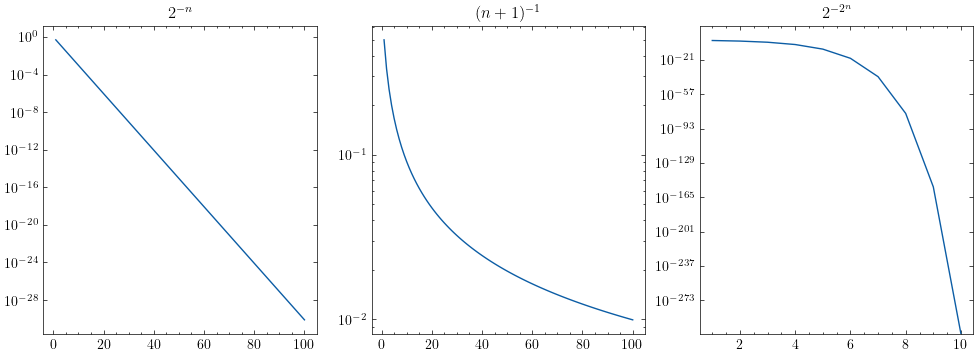

In [2]:
n_vals = [
    np.arange(1, 101, dtype=np.float64),
    np.arange(1, 101, dtype=np.float64),
    np.arange(1, 11, dtype=np.float64),
]
a_vals = [
    [np.power(2, -n) for n in n_vals[0]],
    [np.power(n+1, -1) for n in n_vals[1]],
    [np.power(2, -np.power(2, n)) for n in n_vals[2]],
]
titles = [
    r"$2^{-n}$",
    r"$(n+1)^{-1}$",
    r"$2^{-2^n}$"
]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axs):
    ax.plot(n_vals[i], np.abs(a_vals[i]), "C0")
    ax.set_yscale("log")
    ax.set_title(titles[i])


Is there a good way to find the order $q$, rather than just testing?

Since we have $\lim_{n \to \infty} \frac{|e_{n+1}|}{|e_n|^q} = \mu$, we investigate

$$ |e_{n+1}| \approx \mu |e_n|^q$$

Taking the log of both sides gives

$$ \ln |e_{n+1}| \approx \ln(\mu) + q \cdot \ln|e_n|$$

Thus, if we plot $\ln |e_{n+1}|$ on the $y$-axis, and $\ln |e_{n}|$ on the $x$-axis, we should get $q$ as our gradient, and $\ln(\mu)$ as our intercept. 

An important note is that if we use a log-log scale, but still plot points $|e_{n+1}|$ against $|e_{n}|$ (no $\log$), then we still observe the gradient $q$, and when $|e_{n}| = 1$, we have $|e_{n+1}| = \mu$.

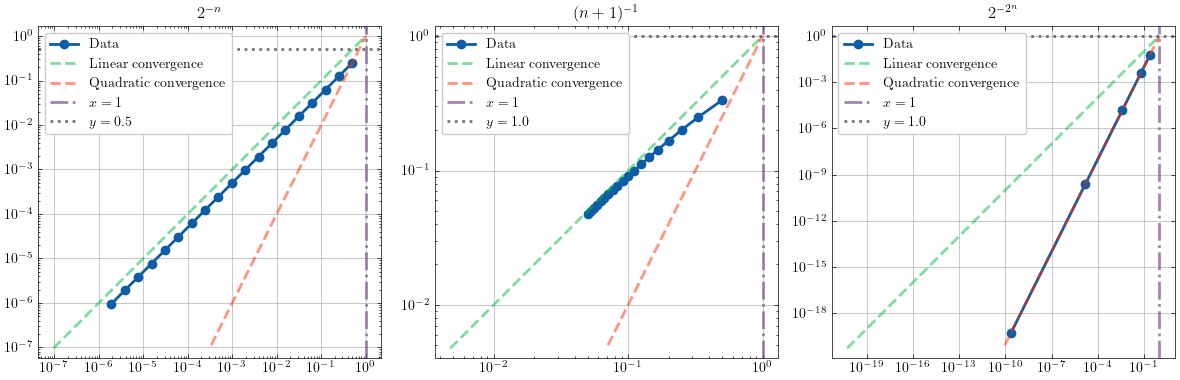

In [3]:
n_vals = [
    np.arange(1, 21, dtype=np.float64),
    np.arange(1, 21, dtype=np.float64),
    np.arange(1, 7, dtype=np.float64),
]
a_vals = [
    [np.power(2, -n) for n in n_vals[0]],
    [np.power(n+1, -1) for n in n_vals[1]],
    [np.power(2, -np.power(2, n)) for n in n_vals[2]],
]
intercepts = [
    [0.5, r"$0.5$"], [1.0, r"$1.0$"], [1.0, r"$1.0$"]
]
titles = [
    r"$2^{-n}$",
    r"$(n+1)^{-1}$",
    r"$2^{-2^n}$"
]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axs):
    ax.loglog(np.abs(a_vals[i][:-1]), np.abs(a_vals[i][1:]), 'C0o-', linewidth=2, label='Data')
    
    grid = np.logspace(np.log10(min(a_vals[i]))-1, 0, 100)
    ax.loglog(grid, grid, 'C1--',  linewidth=2, alpha=0.5, label='Linear convergence')
    ax.loglog(grid[grid**2 >= grid.min()], grid[grid**2 >= grid.min()]**2, 'C3--', linewidth=2, alpha=0.5, label='Quadratic convergence')

    ax.axvline(1, color='C4', linestyle='dashdot', alpha=0.75, linewidth=2, label=r"$x=1$")
    ax.axhline(intercepts[i][0], color='C5', linestyle="dotted", alpha=0.75, linewidth=2, label=f"$y={intercepts[i][0]}$")
    ax.axis("equal")
    
    ax.grid()
    ax.set_title(titles[i])
    ax.legend(loc='upper left', facecolor='white', framealpha=1.0, frameon=True)
    
plt.tight_layout()

#### **(a)**
We see a clear gradient of $p=1$, with the intercept of $\mu=0.5$.

#### **(b)**
We see that the line the data tends to has a gradient of $p=1$, and the line it tends to has an intercept of $\mu=1$.

#### **(c)**
We see a clear gradient of $p=2$, with the intercept of $\mu=1$.

## Question 2.

Let $(X, d)$ be a metric space, i.e. $d$ satisfies symmetry, the triangle inequality and $d(x, y) = 0 \iff x=y$

Then, a map $T: X \to X$ is called a contraction if there exists a constant $0 \le c \le 1$ such that
$$ d(T(x), T(y)) \le c\,d(x, y)$$
for all $x, y \in X$.

If we assume the standard metric $d(x, y) = |x - y|$, then we can say that a function is a contraction if it is an endomorphism and has a Lipschitz constant $L < 1$.

### (a) $X = \left[ \frac{3\pi}{4}, \frac{5\pi}{4} \right], \quad g(x) = \sin(x) + x$

As $g'(x) = \cos(x) + 1$ we have $g'(x) \ge 0$, so it is non-decreasing. Therefore, as $g(\min(X)) > \min(X)$, and $g(\max(X)) < \max(X)$, it is an endomorphism.

Further $\sup(\cos(X)) = -\frac{\sqrt{2}}{2}$, and so we have a Lipschitz constant of $L = 1 - \frac{\sqrt{2}}{2}$


Thus, it is a contraction, and Banach's contraction mapping theorem tells us there is a fixed point.

### (b) $X = [0, 2], \quad g(x) = x^3 + 3x^2 - 3$

Simply, as $g(\max(X)) = g(2) = 17$, and  $17 > \max(X)$, it is not an endomorphism.

Thus, Banach's contraction mapping theorem does not apply.

### (c) $X = [1, \infty), \quad g(x) = x + x^{-1}$

As $g'(x) = 1 - x^{-2}$ we have $g'(x) \ge 0$ on $X$, so it is non-decreasing. 

Therefore, as $g(\min(X)) = 2 > \min(X)$, and $\lim_{x \to \infty} g(x) = \infty$, it is an endomorphism.

However, $\sup(g'(X)) = \lim_{x \to \infty} \left(1 - \frac{1}{x^2}\right) = 1$, and so we have a Lipschitz constant of $L = 1$.

Thus, it is not a contraction (as we require $L < 1$), and Banach's contraction mapping theorem does not apply.

**1. Prove it's an endomorphism:**

I.e. $\text{Graph}(T) \subseteq X^2$

**2. Prove that the Lipschitz Constant is strictly less than 1:**


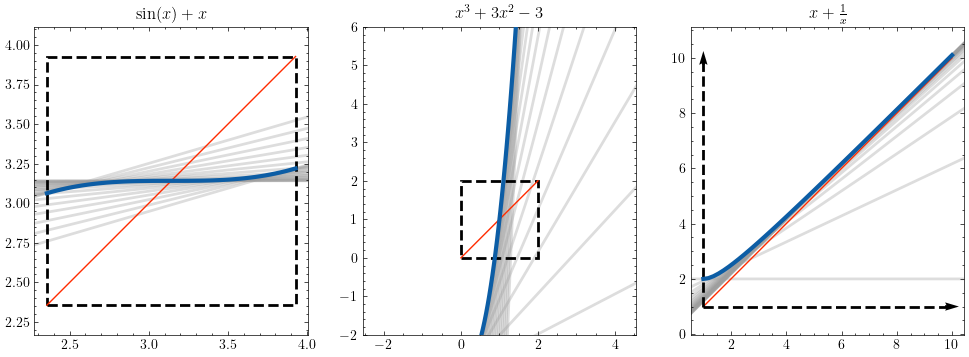

In [4]:
x_lims = [
    [3 * np.pi / 4, 5 * np.pi / 4],
    [0, 2],
    [1, 10]
]
f = [
    lambda x: np.sin(x) + x,
    lambda x: x**3 + 3 * x**2 - 3,
    lambda x: x + (1 / x)
]
df = [
    lambda x: np.cos(x) + 1,
    lambda x: 3 * x**2 + 6 * x,
    lambda x: 1 - (1 / x**2)
]
titles = [
    r"$\sin(x) + x$",
    r"$x^3 + 3x^2 - 3$",
    r"$x + \frac{1}{x}$"
]


fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axs):
    low, high = x_lims[i]
    
    xs = np.linspace(low, high)
    x_tangents = np.linspace(low, high, 25)
    y_tangents = f[i](x_tangents)

    u = np.ones_like(x_tangents)
    v = df[i](x_tangents)          

    ax.plot(xs, f[i](xs), linewidth=3, c="C0", zorder=3)
    ax.quiver(x_tangents, y_tangents, u, v, color='C6', 
            angles='xy', scale_units='xy', scale=0.001, width=0.01, pivot='mid', label="Tangents", zorder=0, alpha=0.35,)
    ax.plot(xs, xs, c="C3", linewidth=1,)
    ax.axis("equal")
    
    if i == 1:
        ax.set_ylim(-2, 6)
    
    
    if i < 2:
        rect = patches.Rectangle((low, low), high-low, high-low, 
                                 linewidth=2, edgecolor='k', facecolor='none',
                                 linestyle='--', label="Domain $X$")
        ax.add_patch(rect)
    else:
        ax.hlines(1, 1, high, colors='k', linewidth=2, linestyle="--")
        ax.vlines(1, 1, high, colors='k', linewidth=2, linestyle="--")
        ax.quiver([high-0.25, 1], [1, high-0.25], [1, 0], [0, 1], color='k', 
                        angles='xy', scale_units='xy', scale=2, width=0.015)
    
    ax.set_title(titles[i])

In [5]:
def sine(x):
    term = x
    result = x
    for n in range(1, 101):
        term *= -x * x / ((2 * n) * (2 * n + 1))
        result += term
    return result

x = 3
for _ in range(100):
    x = sine(x) + x
    
print(x)
print(np.pi)

3.1415926535897936
3.141592653589793


## Question 3.

### (a)

Given $e_{n+1}\approx M e_{n}^q$, then
$\log{e_{n+1}} \approx \log(M) + q \log(e_n)$

$$ \log{e_{n+2}}-\log{e_{n+1}} \approx q \left( \log(e_{n+1}) - \log(e_n) \right)$$
i.e.
$$ q \approx \dfrac{\log\left(\dfrac{e_{n+2}}{e_{n+1}}\right)}{\log\left(\dfrac{e_{n+1}}{e_{n}}\right)} $$

and then
$$ \log(M) \approx \log{e_{n+1}} - q \log(e_n) \implies M \approx \dfrac{e_{n+1}}{e_n^q}$$

### (b)

#### Generators

In [6]:
from itertools import count, islice

def fib_gen():
    a, b = 0, 1
    while True:
        a, b = b, a + b
        yield a

In [7]:
fib_gen()

<generator object fib_gen at 0x000002D2D2E7F9F0>

In [8]:
[next(fib_gen()) for _ in range(10)]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [9]:
f = fib_gen()
[next(f) for _ in range(10)]

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55]

In [10]:
next(f)

89

In [11]:
from mpmath import mp, fabs, log, pi, mpf

mp.dps = 100

def leibniz():
    summation = 0
    for n in count():
        summation += (-1)**(n % 2) / mpf(2 * n + 1)
        yield 4 * summation

estimates = list(islice(leibniz(), 0, 10_000 + 3))
errors = [fabs(est - pi) for est in estimates]

q = log(errors[-1] / errors[-2]) / log(errors[-2] / errors[-3])

M =  errors[-1] / errors[-2]**q

print(f"q = {float(q):.5f}, M = {float(M):.5f}")

q = 0.99990, M = 0.99898


It seems like we have roughly order of convergence and rate equal to 1, meaning sublinear convergence

In [12]:
type(q)

mpmath.ctx_mp_python.mpf

In [13]:
print(estimates)

[mpf('4.0'), mpf('2.666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666648'), mpf('3.466666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666666642'), mpf('2.895238095238095238095238095238095238095238095238095238095238095238095238095238095238095238095238095217'), mpf('3.339682539682539682539682539682539682539682539682539682539682539682539682539682539682539682539682539659'), mpf('2.976046176046176046176046176046176046176046176046176046176046176046176046176046176046176046176046176017'), mpf('3.283738483738483738483738483738483738483738483738483738483738483738483738483738483738483738483738483707'), mpf('3.017071817071817071817071817071817071817071817071817071817071817071817071817071817071817071817071817042'), mpf('3.252365934718875895346483581777699424758248287660052365934718875895346483581777699424758248287660052335'), mpf('3.0418396189294022111359572659882257405477219718705786817241925601058727993712

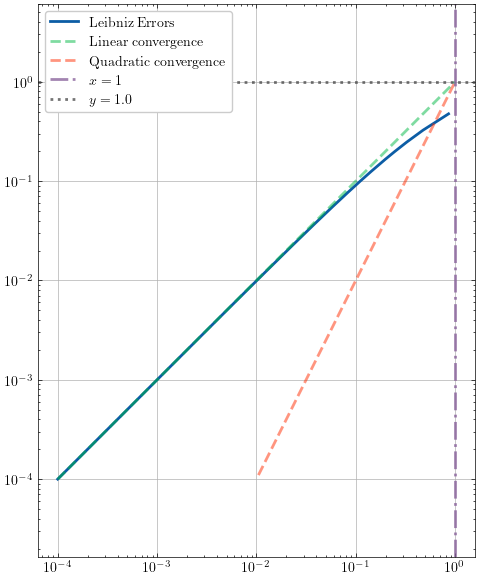

In [14]:
fig, ax = plt.subplots(figsize=(5, 6))

x_data = errors[:-1]
y_data = errors[1:]

grid = np.logspace(np.log10(1e-4), 0, 100)

ax.loglog(x_data, y_data, 'C0-', linewidth=2, label='Leibniz Errors')
ax.loglog(grid, grid, 'C1--', linewidth=2, alpha=0.5, label='Linear convergence')
ax.loglog(grid[grid**2 >= grid.min()], grid[grid**2 >= grid.min()]**2, 'C3--', linewidth=2, alpha=0.5, label='Quadratic convergence')
ax.axvline(1, color='C4', linestyle='dashdot', alpha=0.75, linewidth=2, label=r"$x=1$")
ax.axhline(intercepts[i][0], color='C5', linestyle="dotted", alpha=0.75, linewidth=2, label=f"$y={intercepts[i][0]}$")

ax.grid()
ax.legend(loc='upper left', facecolor='white', framealpha=1.0, frameon=True)
ax.axis("equal")

plt.tight_layout()
plt.show()

### (c)

In [15]:
def aitken(seq):
    values = (next(seq), next(seq), next(seq))
    
    while True:
        ahat = values[0] - ((values[1] - values[0])**2 / (values[2] -2*values[1] + values[0]))
        yield ahat
        
        values = (values[1], values[2], next(seq))

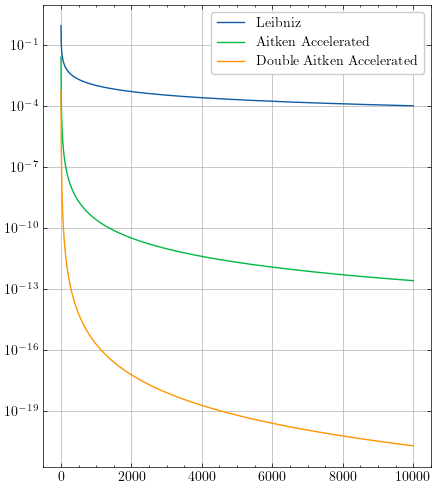

In [16]:
estimates_accelerated = list(islice(aitken(leibniz()), 0, 10_003))
errors_accelerated = [fabs(est - pi) for est in estimates_accelerated]

estimates_accelerated_twice = list(islice(aitken(aitken(leibniz())), 0, 10_003))
errors_accelerated_twice = [fabs(est - pi) for est in estimates_accelerated_twice]

fig, ax = plt.subplots(figsize=(5, 6))

ax.plot(np.arange(10_003), errors, c="C0", label="Leibniz")
ax.plot(np.arange(10_003), errors_accelerated, c="C1", label="Aitken Accelerated")
ax.plot(np.arange(10_003), errors_accelerated_twice, c="C2", label="Double Aitken Accelerated")
ax.set_yscale("log")
ax.legend(loc='upper right', facecolor='white', framealpha=1.0, frameon=True)
ax.grid()

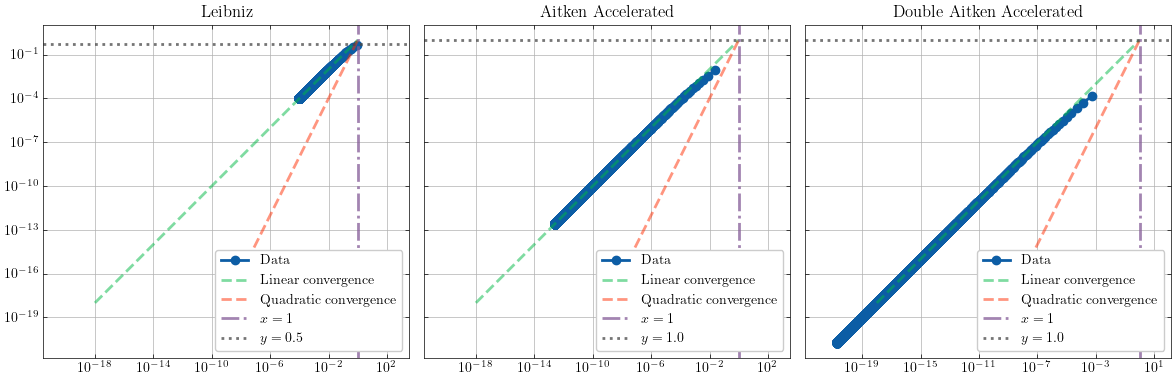

In [17]:
y_vals = [
    errors,
    errors_accelerated,
    errors_accelerated_twice
]

titles = [
    "Leibniz",
    "Aitken Accelerated",
    "Double Aitken Accelerated"
]

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, ax in enumerate(axs):
    ax.loglog(np.abs(y_vals[i][:-1]), np.abs(y_vals[i][1:]), 'C0o-', linewidth=2, label='Data')
    
    grid = np.logspace(np.log10(1e-18), 0, 100)
    
    ax.loglog(grid, grid, 'C1--',  linewidth=2, alpha=0.5, label='Linear convergence')
    ax.loglog(grid[grid**2 >= grid.min()], grid[grid**2 >= grid.min()]**2, 'C3--', linewidth=2, alpha=0.5, label='Quadratic convergence')

    ax.axvline(1, color='C4', linestyle='dashdot', alpha=0.75, linewidth=2, label=r"$x=1$")
    ax.axhline(intercepts[i][0], color='C5', linestyle="dotted", alpha=0.75, linewidth=2, label=f"$y={intercepts[i][0]}$")

    ax.axis("equal")
    ax.grid()
    ax.set_title(titles[i])
    ax.legend(loc='lower right', facecolor='white', framealpha=1.0, frameon=True)
    
plt.tight_layout()